## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft
from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

In [3]:
# Path to BIDMC PhysioNet dataset
data_dir = Path(
    r"G:\1-1- Articles\1- Hybrid_Quantum_STATE_PREPRATION_VIA_DATA_COMPRESSION\Datasets\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv"
)

signal_files = sorted(
    data_dir.glob("*_Signals.csv")
)

print(f"Found {len(signal_files)} files")

Found 53 files


In [4]:
def load_ppg_signal(file_path):
    """
    Load a PPG waveform, zero-pad it to the next
    power of two, and normalize it.
    """

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()

    signal = df["PLETH"].astype(float).values

    # Zero-padding
    N_orig = len(signal)

    next_pow2 = 2 ** math.ceil(
        math.log2(N_orig)
    )

    pad_len = next_pow2 - N_orig

    signal = np.pad(
        signal,
        (0, pad_len),
        mode="constant"
    )

    # Normalization
    signal = (
        signal /
        np.linalg.norm(signal)
    )

    return signal

In [5]:
# ------------------------------------------------------------
# Evaluate DFT compression for a given sparsity k
# ------------------------------------------------------------

def analyze_ppg_dataset(k):

    td_values = []

    for file in signal_files:

        signal = load_ppg_signal(file)

        coeffs = np.fft.fft(signal)

        coeffs = top_k_threshold(
            coeffs,
            k
        )

        coeffs /= np.linalg.norm(coeffs)

        reconstructed = np.fft.ifft(coeffs)

        reconstructed = np.real_if_close(reconstructed)
        reconstructed /= np.linalg.norm(reconstructed)

        td = trace_distance(
            signal,
            reconstructed
        )

        td_values.append(td)

    td_values = np.asarray(td_values)

    return (
        td_values.mean(),
        td_values.std()
    )

In [6]:
# ------------------------------------------------------------
# Sparsity regimes
# ------------------------------------------------------------

n = 16

k_values = [
    n,
    2 * n,
    5 * n,
    7 * n,
    10 * n,
    n**2,
    2 * n**2,
    4 * n**2,
    6 * n**2,
    12 * n**2,
]

labels = [
    r"$n$",
    r"$2n$",
    r"$5n$",
    r"$7n$",
    r"$10n$",
    r"$n^2$",
    r"$2n^2$",
    r"$4n^2$",
    r"$6n^2$",
    r"$12n^2$",
]

means = []
stds = []

for k in k_values:

    mean_td, std_td = analyze_ppg_dataset(k)

    means.append(mean_td)
    stds.append(std_td)

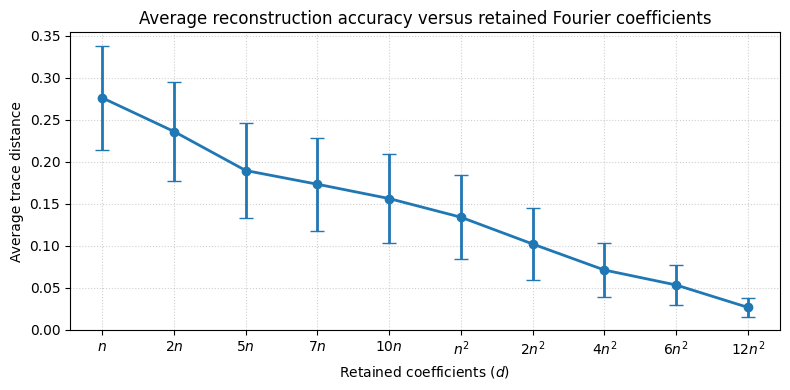

In [9]:
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.errorbar(
    labels,
    means,
    yerr=stds,
    fmt="o-",
    color="tab:blue",
    linewidth=2,
    markersize=6,
    capsize=5,
)
plt.title("Average reconstruction accuracy versus retained Fourier coefficients")
plt.xlabel("Retained coefficients ($d$)")
plt.ylabel("Average trace distance")

plt.grid(
    True,
    linestyle=":",
    alpha=0.6,
)

plt.tight_layout()


plt.savefig(
    "../figures/PPG_DFT_analysis.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()